# 01_preprocessing_check

전처리된 KMP 통신사 이탈 데이터의 기본 구조, 라벨 분포, 전환 구조, 주요 입력 변수 분포를 확인한다.

## 1. 전처리 데이터 기본 구조 및 라벨 확인

이 섹션에서는 전처리된 데이터가 어떤 단위로 구성되어 있는지,
라벨이 어떤 비율로 분포하는지, 통신사 이동 구조가 어떻게 나타나는지를 확인한다.

특히 아래 내용을 중심으로 살펴본다.

- 한 행이 무엇을 의미하는지
- 전체 통신사 변경 여부(`churn_any`) 분포
- 메이저 통신사에서 MVNO로 이동한 경우(`churn_to_mvno`) 분포
- 연도 전환 구간별 표본 수
- 시작 통신사 분포
- 실제 통신사 이동 방향
- 시작 통신사별 이탈 비율

이를 통해 전처리된 CSV가 전체적으로 어떤 구조를 가지는지 먼저 파악한다.

기본 정보
shape: (41299, 17)

컬럼 목록
['pid', 'year_t0', 'year_t1', 'telco_t0', 'telco_t1', 'churn_any', 'churn_to_mvno', 'a03002_tminus1', 'a03024_tminus1', 'a03026_tminus1', 'c01002_tminus1', 'c01004_tminus1', 'c02003_tminus1', 'c02001_tminus1', 'age1_tminus1', 'income1_tminus1', 'job1_tminus1']


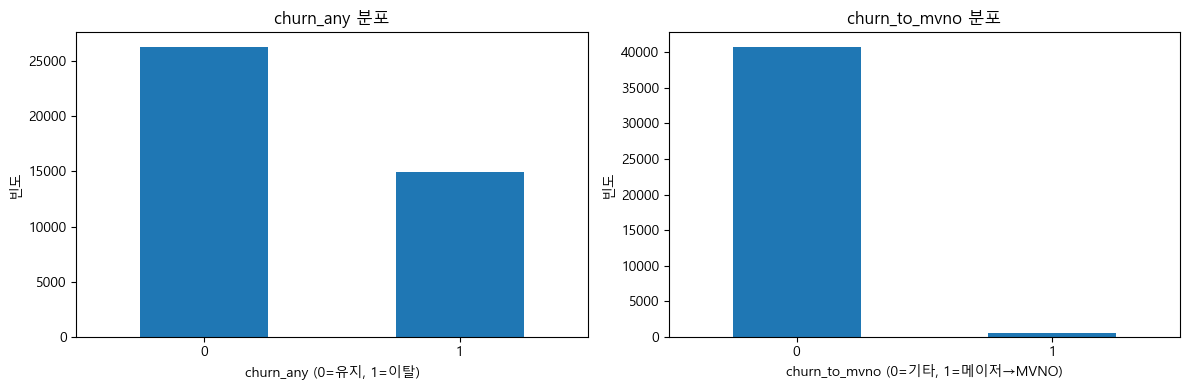


라벨 분포

[churn_any]
churn_any
0    26317
1    14982
Name: count, dtype: int64

[churn_to_mvno]
churn_to_mvno
0    40784
1      515
Name: count, dtype: int64


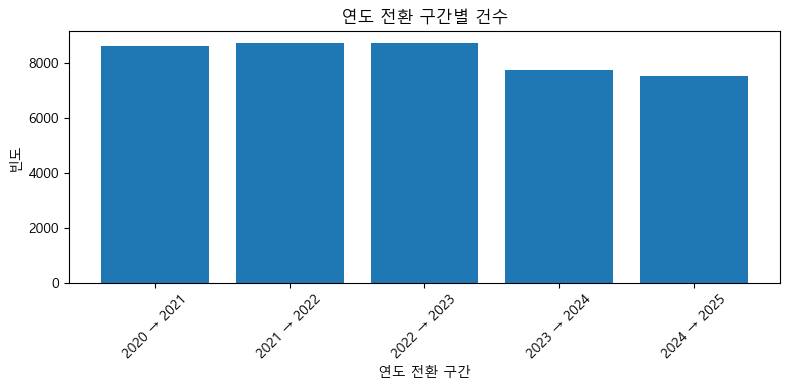


연도 전환 구간별 건수


,year_t0,year_t1,count
0,2020,2021,8612
1,2021,2022,8708
2,2022,2023,8714
3,2023,2024,7730
4,2024,2025,7535


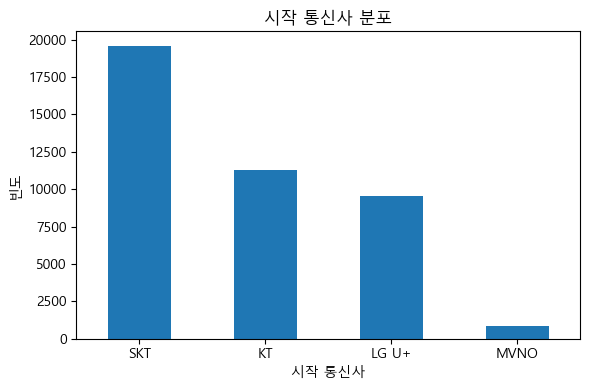


시작 통신사 분포
telco_t0
SKT      19579
KT       11295
LG U+     9566
MVNO       859
Name: count, dtype: int64


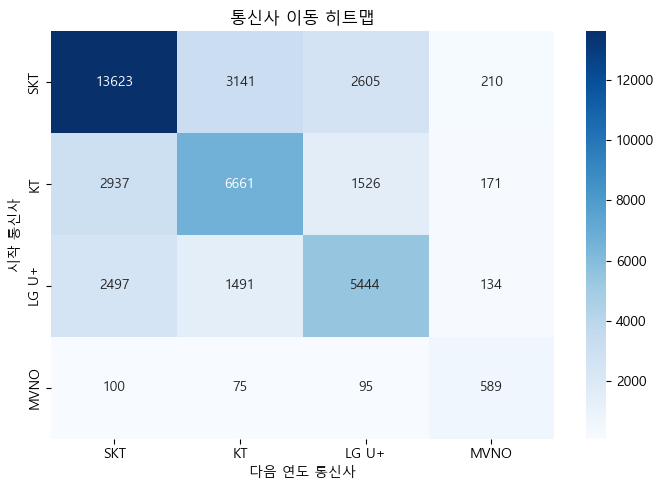


통신사 이동 행렬


telco_t1,SKT,KT,LG U+,MVNO
telco_t0,,,,
SKT,13623,3141,2605,210
KT,2937,6661,1526,171
LG U+,2497,1491,5444,134
MVNO,100,75,95,589


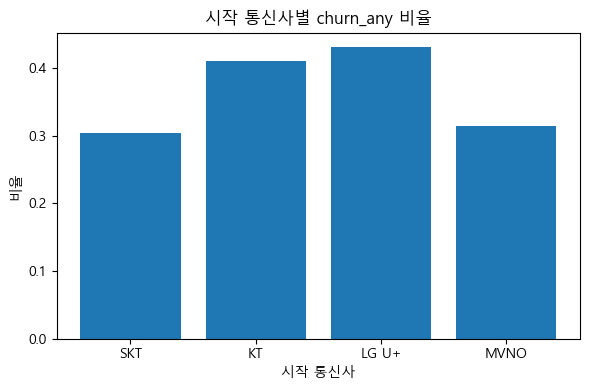


시작 통신사별 churn_any 비율


,telco_t0_label,churn_any
0,SKT,0.304203
1,KT,0.410270
2,LG U+,0.430901
3,MVNO,0.314319



[해석] 기본 구조 확인
- 현재 데이터는 pid 기준의 전환형 롱패널 구조이며, 한 행은 year_t0에서 year_t1로의 이동을 의미한다.
- churn_any는 전체 통신사 변경 여부, churn_to_mvno는 메이저 통신사에서 알뜰폰으로 이동한 경우만 1로 정의된다.
- 시작 통신사 분포와 전환 행렬을 통해 어떤 통신사에서 어떤 방향으로 이동이 많이 발생하는지 확인할 수 있다.
- 시작 통신사별 churn_any 비율을 함께 보면 특정 통신사에서 상대적으로 이동 가능성이 높은지도 파악할 수 있다.


In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# ---------------------------------------
# 0. 데이터 불러오기
# ---------------------------------------
df = pd.read_csv("../data/processed/train_df_2020_2025.csv", encoding="utf-8-sig")

# ============================================================
# 1. 기본 구조 확인
# ============================================================

# 데이터 기본 정보
print("=" * 70)
print("기본 정보")
print("=" * 70)
print("shape:", df.shape)
print("\n컬럼 목록")
print(df.columns.tolist())

# ------------------------------------------------------------
# 1-1. 라벨 분포
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["churn_any"].value_counts().sort_index().plot(kind="bar", ax=axes[0])
axes[0].set_title("churn_any 분포")
axes[0].set_xlabel("churn_any (0=유지, 1=이탈)")
axes[0].set_ylabel("빈도")
axes[0].tick_params(axis="x", rotation=0)

df["churn_to_mvno"].value_counts().sort_index().plot(kind="bar", ax=axes[1])
axes[1].set_title("churn_to_mvno 분포")
axes[1].set_xlabel("churn_to_mvno (0=기타, 1=메이저→MVNO)")
axes[1].set_ylabel("빈도")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("라벨 분포")
print("=" * 70)
print("\n[churn_any]")
print(df["churn_any"].value_counts(dropna=False).sort_index())
print("\n[churn_to_mvno]")
print(df["churn_to_mvno"].value_counts(dropna=False).sort_index())

# ------------------------------------------------------------
# 1-2. 연도 전환 구간별 건수
# ------------------------------------------------------------
transition_counts = (
    df.groupby(["year_t0", "year_t1"])
      .size()
      .reset_index(name="count")
)
transition_counts["transition"] = (
    transition_counts["year_t0"].astype(str) + " → " + transition_counts["year_t1"].astype(str)
)

plt.figure(figsize=(8, 4))
plt.bar(transition_counts["transition"], transition_counts["count"])
plt.title("연도 전환 구간별 건수")
plt.xlabel("연도 전환 구간")
plt.ylabel("빈도")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("연도 전환 구간별 건수")
print("=" * 70)
display(transition_counts[["year_t0", "year_t1", "count"]])

# ------------------------------------------------------------
# 1-3. 시작 통신사 분포
# ------------------------------------------------------------
telco_map = {
    1: "SKT",
    2: "KT",
    3: "LG U+",
    4: "MVNO"
}

telco_t0_counts = df["telco_t0"].map(telco_map).value_counts().reindex(["SKT", "KT", "LG U+", "MVNO"])

plt.figure(figsize=(6, 4))
telco_t0_counts.plot(kind="bar")
plt.title("시작 통신사 분포")
plt.xlabel("시작 통신사")
plt.ylabel("빈도")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("시작 통신사 분포")
print("=" * 70)
print(telco_t0_counts)

# ------------------------------------------------------------
# 1-4. 통신사 이동 히트맵
# ------------------------------------------------------------
transition_matrix = pd.crosstab(
    df["telco_t0"].map(telco_map),
    df["telco_t1"].map(telco_map)
).reindex(index=["SKT", "KT", "LG U+", "MVNO"], columns=["SKT", "KT", "LG U+", "MVNO"])

plt.figure(figsize=(7, 5))
sns.heatmap(transition_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("통신사 이동 히트맵")
plt.xlabel("다음 연도 통신사")
plt.ylabel("시작 통신사")
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("통신사 이동 행렬")
print("=" * 70)
display(transition_matrix)

# ------------------------------------------------------------
# 1-5. 시작 통신사별 churn_any 비율
# ------------------------------------------------------------
telco_churn_rate = (
    df.groupby("telco_t0")["churn_any"]
      .mean()
      .reset_index()
)
telco_churn_rate["telco_t0_label"] = telco_churn_rate["telco_t0"].map(telco_map)

plt.figure(figsize=(6, 4))
plt.bar(telco_churn_rate["telco_t0_label"], telco_churn_rate["churn_any"])
plt.title("시작 통신사별 churn_any 비율")
plt.xlabel("시작 통신사")
plt.ylabel("비율")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("시작 통신사별 churn_any 비율")
print("=" * 70)
display(telco_churn_rate[["telco_t0_label", "churn_any"]])

# ------------------------------------------------------------
# 1-6. 해석
# ------------------------------------------------------------
print("\n[해석] 기본 구조 확인")
print("- 현재 데이터는 pid 기준의 전환형 롱패널 구조이며, 한 행은 year_t0에서 year_t1로의 이동을 의미한다.")
print("- churn_any는 전체 통신사 변경 여부, churn_to_mvno는 메이저 통신사에서 알뜰폰으로 이동한 경우만 1로 정의된다.")
print("- 시작 통신사 분포와 전환 행렬을 통해 어떤 통신사에서 어떤 방향으로 이동이 많이 발생하는지 확인할 수 있다.")
print("- 시작 통신사별 churn_any 비율을 함께 보면 특정 통신사에서 상대적으로 이동 가능성이 높은지도 파악할 수 있다.")

In [29]:
# ============================================================
# 공통. 표시용 컬럼명 매핑
# ============================================================
FEATURE_LABEL_MAP = {
    "a03002_tminus1": "스마트폰 구분",
    "a03024_tminus1": "음성 무제한 서비스 가입 여부",
    "a03026_tminus1": "데이터 무제한 서비스 가입 여부",
    "c01002_tminus1": "월평균 휴대폰 이용 총 금액",
    "c01004_tminus1": "월평균 기기 할부금",
    "c02003_tminus1": "휴대폰 결합상품 가입 여부",
    "c02001_tminus1": "휴대폰 요금 부담자",
    "age1_tminus1": "나이",
    "income1_tminus1": "개인 월평균 소득",
    "job1_tminus1": "직업 유무"
}

TARGET_LABEL_MAP = {
    "churn_any": "전체 통신사 변경 여부",
    "churn_to_mvno": "메이저 → 알뜰폰 이동 여부"
}

def rename_feature_label(col_name):
    return FEATURE_LABEL_MAP.get(col_name, col_name)

def rename_feature_series(series):
    return series.map(lambda x: FEATURE_LABEL_MAP.get(x, x))

In [30]:
# ============================================================
# 추가. 전처리 기준 및 컬럼 설명 표
# ============================================================
feature_desc_df = pd.DataFrame({
    "원본 컬럼명": list(FEATURE_LABEL_MAP.keys()),
    "표시용 이름": list(FEATURE_LABEL_MAP.values())
})

display(feature_desc_df)

preprocess_rule_df = pd.DataFrame({
    "전처리 항목": [
        "결측 코드 처리",
        "공백 / NBSP 제거",
        "통신사 유효값 유지",
        "이진 변수 1/2 → 1/0 변환",
        "중복 제거",
        "누수 방지",
        "개인 배경 변수 추가"
    ],
    "설명": [
        "9999, 9998, 9997을 NaN으로 변환",
        "문자형 컬럼의 불필요한 공백 제거",
        "통신사 코드는 {1, 2, 3, 4}만 유지",
        "일부 이진 변수는 모델 입력에 맞게 1/0으로 정리",
        "pid, year_t0, year_t1 기준 중복 제거",
        "예측에는 t-1 변수만 사용하고 telco 관련 컬럼은 제외",
        "나이(age1), 개인 월평균 소득(income1), 직업 유무(job1)를 추가"
    ]
})

display(preprocess_rule_df)

print("\n[해석] 전처리 확장")
print("- 기존 통신 이용 특성 변수에 더해 나이, 개인 월평균 소득, 직업 유무가 추가되었다.")
print("- 따라서 현재 데이터는 이용 패턴뿐 아니라 개인 배경 특성까지 함께 반영하는 구조로 확장되었다.")
print("- 특히 churn_to_mvno처럼 희소한 이동에서는 이러한 배경 변수 보강이 설명력 향상에 도움이 될 수 있다.")

,원본 컬럼명,표시용 이름
0,a03002_tminus1,스마트폰 구분
1,a03024_tminus1,음성 무제한 서비스 가입 여부
2,a03026_tminus1,데이터 무제한 서비스 가입 여부
3,c01002_tminus1,월평균 휴대폰 이용 총 금액
4,c01004_tminus1,월평균 기기 할부금
5,c02003_tminus1,휴대폰 결합상품 가입 여부
6,c02001_tminus1,휴대폰 요금 부담자
7,age1_tminus1,나이
8,income1_tminus1,개인 월평균 소득
9,job1_tminus1,직업 유무


,전처리 항목,설명
0,결측 코드 처리,"9999, 9998, 9997을 NaN으로 변환"
1,공백 / NBSP 제거,문자형 컬럼의 불필요한 공백 제거
2,통신사 유효값 유지,"통신사 코드는 {1, 2, 3, 4}만 유지"
3,이진 변수 1/2 → 1/0 변환,일부 이진 변수는 모델 입력에 맞게 1/0으로 정리
4,중복 제거,"pid, year_t0, year_t1 기준 중복 제거"
5,누수 방지,예측에는 t-1 변수만 사용하고 telco 관련 컬럼은 제외
6,개인 배경 변수 추가,"나이(age1), 개인 월평균 소득(income1), 직업 유무(job1)를 추가"



[해석] 전처리 확장
- 기존 통신 이용 특성 변수에 더해 나이, 개인 월평균 소득, 직업 유무가 추가되었다.
- 따라서 현재 데이터는 이용 패턴뿐 아니라 개인 배경 특성까지 함께 반영하는 구조로 확장되었다.
- 특히 churn_to_mvno처럼 희소한 이동에서는 이러한 배경 변수 보강이 설명력 향상에 도움이 될 수 있다.


## 2. 주요 입력 변수 분포 확인

이 섹션에서는 기존 핵심 통신 이용 특성 변수들이 어떤 값에 많이 분포하는지 확인한다.

특히 아래 내용을 중심으로 본다.

- 스마트폰 구분
- 음성 무제한 서비스 가입 여부
- 데이터 무제한 서비스 가입 여부
- 월평균 휴대폰 이용 총 금액

이를 통해 데이터가 어떤 통신 이용 특성을 가진 사용자 집단으로 구성되어 있는지 직관적으로 파악할 수 있다.

추가된 개인 배경 변수인 나이, 개인 월평균 소득, 직업 유무는 뒤의 전처리 검증 체크리스트에서 함께 점검한다.

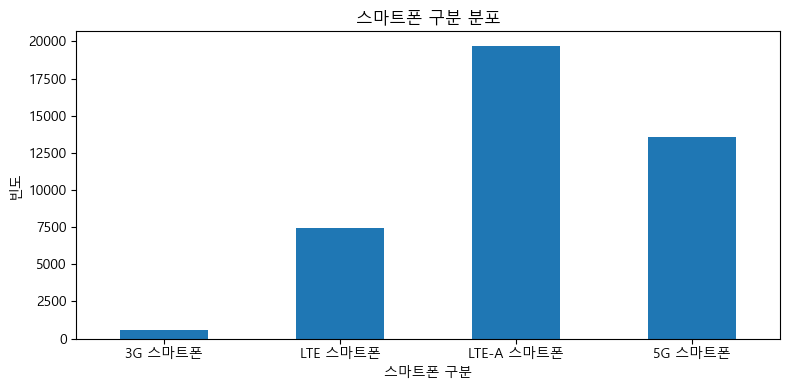


1. a03002_tminus1 : 스마트폰 구분
a03002_tminus1
3G 스마트폰         571
LTE 스마트폰       7469
LTE-A 스마트폰    19693
5G 스마트폰       13566
Name: count, dtype: int64

[해석] 스마트폰 구분
- 이 변수는 t-1 시점에 사용 중인 스마트폰의 통신 기술 세대를 의미한다.
- 사용자가 어느 정도 최신 기술 환경에 있는지를 보여주는 변수다.
- 5G 비중이 높다면 상대적으로 최신 단말 또는 최신 통신 환경 이용 비중이 높다고 해석할 수 있다.
- 이 변수는 숫자가 아니라 기술 세대에 대한 범주형 변수로 해석하는 것이 적절하다.


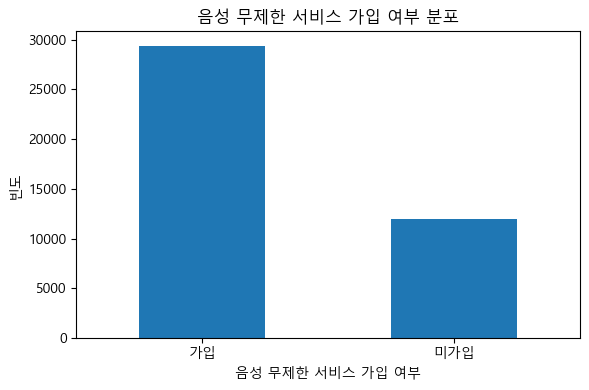


2. a03024_tminus1 : 음성 무제한 서비스 가입 여부
a03024_tminus1
가입     29370
미가입    11929
Name: count, dtype: int64

[해석] 음성 무제한 가입 여부
- 이 변수는 t-1 시점에 음성 통화 무제한 서비스에 가입했는지를 나타낸다.
- 가입 비중이 높다면 현재 통신사에서 음성 혜택을 충분히 받고 있는 사용자가 많다는 뜻일 수 있다.
- 전처리 후에는 1=가입, 0=미가입으로 바뀐 상태다.


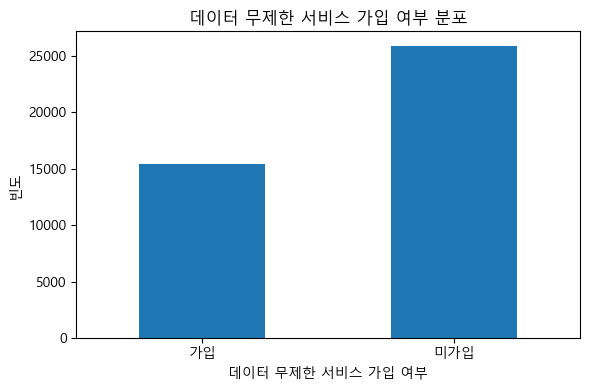


3. a03026_tminus1 : 데이터 무제한 서비스 가입 여부
a03026_tminus1
가입     15404
미가입    25895
Name: count, dtype: int64

[해석] 데이터 무제한 가입 여부
- 이 변수는 t-1 시점에 데이터 무제한 서비스에 가입했는지를 나타낸다.
- 데이터 무제한 가입자는 일반적으로 데이터 사용량이 많거나, 품질/속도에 민감할 가능성이 있다.
- MVNO 이동은 비용 민감성과 관련될 수 있으므로, 이 변수는 churn_to_mvno와 연결해 해석할 가치가 있다.


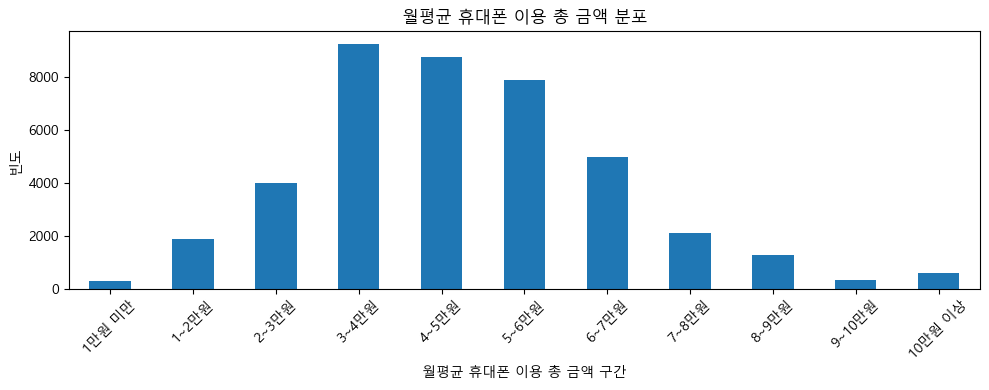


4. c01002_tminus1 : 월평균 휴대폰 이용 총 금액
c01002_tminus1
1만원 미만      299
1~2만원      1877
2~3만원      3977
3~4만원      9241
4~5만원      8747
5~6만원      7870
6~7만원      4971
7~8만원      2115
8~9만원      1259
9~10만원      346
10만원 이상     597
Name: count, dtype: int64

[해석] 월평균 휴대폰 이용 총 금액
- 이 변수는 t-1 시점의 전체 휴대폰 비용 수준을 구간으로 표현한 변수다.
- 실제 금액이 아니라 비용 구간 코드라는 점이 중요하다.
- 어느 구간에 관측치가 많이 몰려 있는지 보면 전체 이용자들의 요금 수준을 대략 파악할 수 있다.
- 통신비 부담 수준을 가장 직접적으로 보여주는 핵심 입력 변수 중 하나다.


In [31]:
# 보기 쉬운 라벨 매핑
a03002_map = {
    1.0: "3G 스마트폰",
    2.0: "LTE 스마트폰",
    3.0: "LTE-A 스마트폰",
    4.0: "5G 스마트폰"
}

binary_map = {
    0.0: "미가입",
    1.0: "가입"
}

cost_map = {
    1.0: "1만원 미만",
    2.0: "1~2만원",
    3.0: "2~3만원",
    4.0: "3~4만원",
    5.0: "4~5만원",
    6.0: "5~6만원",
    7.0: "6~7만원",
    8.0: "7~8만원",
    9.0: "8~9만원",
    10.0: "9~10만원",
    11.0: "10만원 이상"
}

# ---------------------------------------
# 1. a03002_tminus1 : 스마트폰 구분
# ---------------------------------------
smartphone_counts = df["a03002_tminus1"].map(a03002_map).value_counts().reindex(
    ["3G 스마트폰", "LTE 스마트폰", "LTE-A 스마트폰", "5G 스마트폰"]
)

plt.figure(figsize=(8, 4))
smartphone_counts.plot(kind="bar")
plt.title("스마트폰 구분 분포")
plt.xlabel("스마트폰 구분")
plt.ylabel("빈도")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("1. a03002_tminus1 : 스마트폰 구분")
print("=" * 70)
print(smartphone_counts)

print("\n[해석] 스마트폰 구분")
print("- 이 변수는 t-1 시점에 사용 중인 스마트폰의 통신 기술 세대를 의미한다.")
print("- 사용자가 어느 정도 최신 기술 환경에 있는지를 보여주는 변수다.")
print("- 5G 비중이 높다면 상대적으로 최신 단말 또는 최신 통신 환경 이용 비중이 높다고 해석할 수 있다.")
print("- 이 변수는 숫자가 아니라 기술 세대에 대한 범주형 변수로 해석하는 것이 적절하다.")

# ---------------------------------------
# 2. a03024_tminus1 : 음성 무제한 가입 여부
# ---------------------------------------
voice_counts = df["a03024_tminus1"].map(binary_map).value_counts().reindex(["가입", "미가입"])

plt.figure(figsize=(6, 4))
voice_counts.plot(kind="bar")
plt.title("음성 무제한 서비스 가입 여부 분포")
plt.xlabel("음성 무제한 서비스 가입 여부")
plt.ylabel("빈도")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("2. a03024_tminus1 : 음성 무제한 서비스 가입 여부")
print("=" * 70)
print(voice_counts)

print("\n[해석] 음성 무제한 가입 여부")
print("- 이 변수는 t-1 시점에 음성 통화 무제한 서비스에 가입했는지를 나타낸다.")
print("- 가입 비중이 높다면 현재 통신사에서 음성 혜택을 충분히 받고 있는 사용자가 많다는 뜻일 수 있다.")
print("- 전처리 후에는 1=가입, 0=미가입으로 바뀐 상태다.")

# ---------------------------------------
# 3. a03026_tminus1 : 데이터 무제한 가입 여부
# ---------------------------------------
data_counts = df["a03026_tminus1"].map(binary_map).value_counts().reindex(["가입", "미가입"])

plt.figure(figsize=(6, 4))
data_counts.plot(kind="bar")
plt.title("데이터 무제한 서비스 가입 여부 분포")
plt.xlabel("데이터 무제한 서비스 가입 여부")
plt.ylabel("빈도")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("3. a03026_tminus1 : 데이터 무제한 서비스 가입 여부")
print("=" * 70)
print(data_counts)

print("\n[해석] 데이터 무제한 가입 여부")
print("- 이 변수는 t-1 시점에 데이터 무제한 서비스에 가입했는지를 나타낸다.")
print("- 데이터 무제한 가입자는 일반적으로 데이터 사용량이 많거나, 품질/속도에 민감할 가능성이 있다.")
print("- MVNO 이동은 비용 민감성과 관련될 수 있으므로, 이 변수는 churn_to_mvno와 연결해 해석할 가치가 있다.")

# ---------------------------------------
# 4. c01002_tminus1 : 월평균 휴대폰 이용 총 금액
# ---------------------------------------
cost_counts = df["c01002_tminus1"].map(cost_map).value_counts().reindex([
    "1만원 미만", "1~2만원", "2~3만원", "3~4만원", "4~5만원",
    "5~6만원", "6~7만원", "7~8만원", "8~9만원", "9~10만원", "10만원 이상"
])

plt.figure(figsize=(10, 4))
cost_counts.plot(kind="bar")
plt.title("월평균 휴대폰 이용 총 금액 분포")
plt.xlabel("월평균 휴대폰 이용 총 금액 구간")
plt.ylabel("빈도")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("4. c01002_tminus1 : 월평균 휴대폰 이용 총 금액")
print("=" * 70)
print(cost_counts)

print("\n[해석] 월평균 휴대폰 이용 총 금액")
print("- 이 변수는 t-1 시점의 전체 휴대폰 비용 수준을 구간으로 표현한 변수다.")
print("- 실제 금액이 아니라 비용 구간 코드라는 점이 중요하다.")
print("- 어느 구간에 관측치가 많이 몰려 있는지 보면 전체 이용자들의 요금 수준을 대략 파악할 수 있다.")
print("- 통신비 부담 수준을 가장 직접적으로 보여주는 핵심 입력 변수 중 하나다.")

In [32]:
# ============================================================
# 추가. 전처리 검증 체크리스트
# ============================================================
check_rows = []

check_rows.append({
    "점검 항목": "전체 결측 개수",
    "값": int(df.isna().sum().sum())
})

check_rows.append({
    "점검 항목": "중복 row 개수 (pid, year_t0, year_t1 기준)",
    "값": int(df.duplicated(subset=["pid", "year_t0", "year_t1"]).sum())
})

check_rows.append({
    "점검 항목": "churn_any 평균",
    "값": round(df["churn_any"].mean(), 4)
})

check_rows.append({
    "점검 항목": "churn_to_mvno 평균",
    "값": round(df["churn_to_mvno"].mean(), 4)
})

label_map = {
    "age1_tminus1": "나이",
    "income1_tminus1": "개인 월평균 소득",
    "job1_tminus1": "직업 유무"
}

for col in ["age1_tminus1", "income1_tminus1", "job1_tminus1"]:
    check_rows.append({
        "점검 항목": f"{label_map[col]} 결측률",
        "값": round(df[col].isna().mean(), 4)
    })
preprocess_check_df = pd.DataFrame(check_rows)
display(preprocess_check_df)

print("\n[추가 변수 기초 확인]")
display(df[["age1_tminus1", "income1_tminus1", "job1_tminus1"]].describe(include="all"))

print("\n[직업 유무 분포]")
display(df["job1_tminus1"].value_counts(dropna=False).sort_index())

print("\n[해석] 추가 변수 점검")
print("- 나이와 개인 월평균 소득이 수치형 변수로 정상 포함되었는지 확인한다.")
print("- 직업 유무가 0/1 이진 변수로 변환되었는지 확인한다.")
print("- 세 변수의 결측률이 0에 가깝다면 전처리 결과는 안정적으로 생성된 것으로 볼 수 있다.")

,점검 항목,값
0,전체 결측 개수,0.0000
1,"중복 row 개수 (pid, year_t0, year_t1 기준)",0.0000
2,churn_any 평균,0.3628
3,churn_to_mvno 평균,0.0125
4,나이 결측률,0.0000
5,개인 월평균 소득 결측률,0.0000
6,직업 유무 결측률,0.0000



[추가 변수 기초 확인]


,age1_tminus1,income1_tminus1,job1_tminus1
count,41299.000000,41299.000000,41299.000000
mean,48.285600,4.897189,0.607836
std,18.566312,3.545603,0.488239
min,6.000000,1.000000,0.000000
25%,34.000000,1.000000,0.000000
50%,51.000000,5.000000,1.000000
75%,62.000000,7.000000,1.000000
max,100.000000,18.000000,1.000000



[직업 유무 분포]


job1_tminus1
0    16196
1    25103
Name: count, dtype: int64


[해석] 추가 변수 점검
- 나이와 개인 월평균 소득이 수치형 변수로 정상 포함되었는지 확인한다.
- 직업 유무가 0/1 이진 변수로 변환되었는지 확인한다.
- 세 변수의 결측률이 0에 가깝다면 전처리 결과는 안정적으로 생성된 것으로 볼 수 있다.


## 3. 요약

이 노트북을 통해 다음을 확인할 수 있다.

- 전처리 데이터는 개인별 연도 전환(`t-1 → t`) 단위로 구성되어 있다.
- `churn_any`는 전체 통신사 이동을, `churn_to_mvno`는 메이저 → MVNO 이동을 의미한다.
- 연도 전환 구간별 표본 수와 시작 통신사 분포를 확인할 수 있다.
- 통신사 이동 히트맵을 통해 실제 이동 방향을 직관적으로 볼 수 있다.
- 주요 입력 변수 분포와 추가 변수 점검을 통해 사용자 통신 이용 특성과 개인 배경 특성을 함께 파악할 수 있다.

이번 전처리 단계에서는 단순 정리뿐 아니라, 예측 시점 기준 정보 누수 방지를 핵심 원칙으로 두었다.  
따라서 입력 변수는 모두 `t-1` 시점 기준으로 구성하였고, 라벨 생성에 직접 연결될 수 있는 통신사 관련 컬럼은 baseline 입력에서 제외하였다.

또한 실제 보고서나 시각화에서는 코드형 변수명을 그대로 쓰기보다, 이해하기 쉬운 표시용 이름을 함께 사용하여 해석 가독성을 높였다.
